### Student Insomnia and Educational Outcome Code

In [3]:
import pandas as pd
import os
import warnings

file_path = "/Users/nityagolla/Downloads/Student Insomnia and Educational Outcomes Dataset.csv"

if os.path.exists(file_path):
    df_student_data = pd.read_csv(file_path)
    print("File loaded successfully.")
else:
    warnings.warn("File could not be loaded!")

File loaded successfully.


In [4]:
# print first five values of all college student data set variables
print(df_student_data.head())

             Timestamp 1. What is your year of study? 2. What is your gender?  \
0  10/24/2024 16:51:15               Graduate student                    Male   
1  10/24/2024 16:51:51                     Third year                    Male   
2  10/24/2024 16:52:21                     First year                  Female   
3  10/24/2024 16:53:00                     Third year                    Male   
4  10/24/2024 16:53:25               Graduate student                    Male   

  3. How often do you have difficulty falling asleep at night?   \
0                           Often (5-6 times a week)              
1                           Often (5-6 times a week)              
2                       Sometimes (3-4 times a week)              
3                           Often (5-6 times a week)              
4                           Often (5-6 times a week)              

  4. On average, how many hours of sleep do you get on a typical day?  \
0                                    

In [5]:
# print college student data set info
print("\nDataset Info:")
print(df_student_data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 16 columns):
 #   Column                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                   --------------  ----- 
 0   Timestamp                                                                                                                791 non-null    object
 1   1. What is your year of study?                                                                                           791 non-null    object
 2   2. What is your gender?                                                                                                  791 non-null    object
 3   3. How often do you have difficulty falling asleep at night?                                                             791 non-n

In [6]:
# print summary of college student data set
print("\nSummary:")
print(df_student_data.describe(include='all'))


Summary:
                  Timestamp 1. What is your year of study?  \
count                   791                            791   
unique                  790                              4   
top     10/24/2024 17:04:15               Graduate student   
freq                      2                            403   

       2. What is your gender?  \
count                      791   
unique                       2   
top                       Male   
freq                       572   

       3. How often do you have difficulty falling asleep at night?   \
count                                                 791              
unique                                                  5              
top                              Often (5-6 times a week)              
freq                                                  369              

       4. On average, how many hours of sleep do you get on a typical day?  \
count                                                 791            

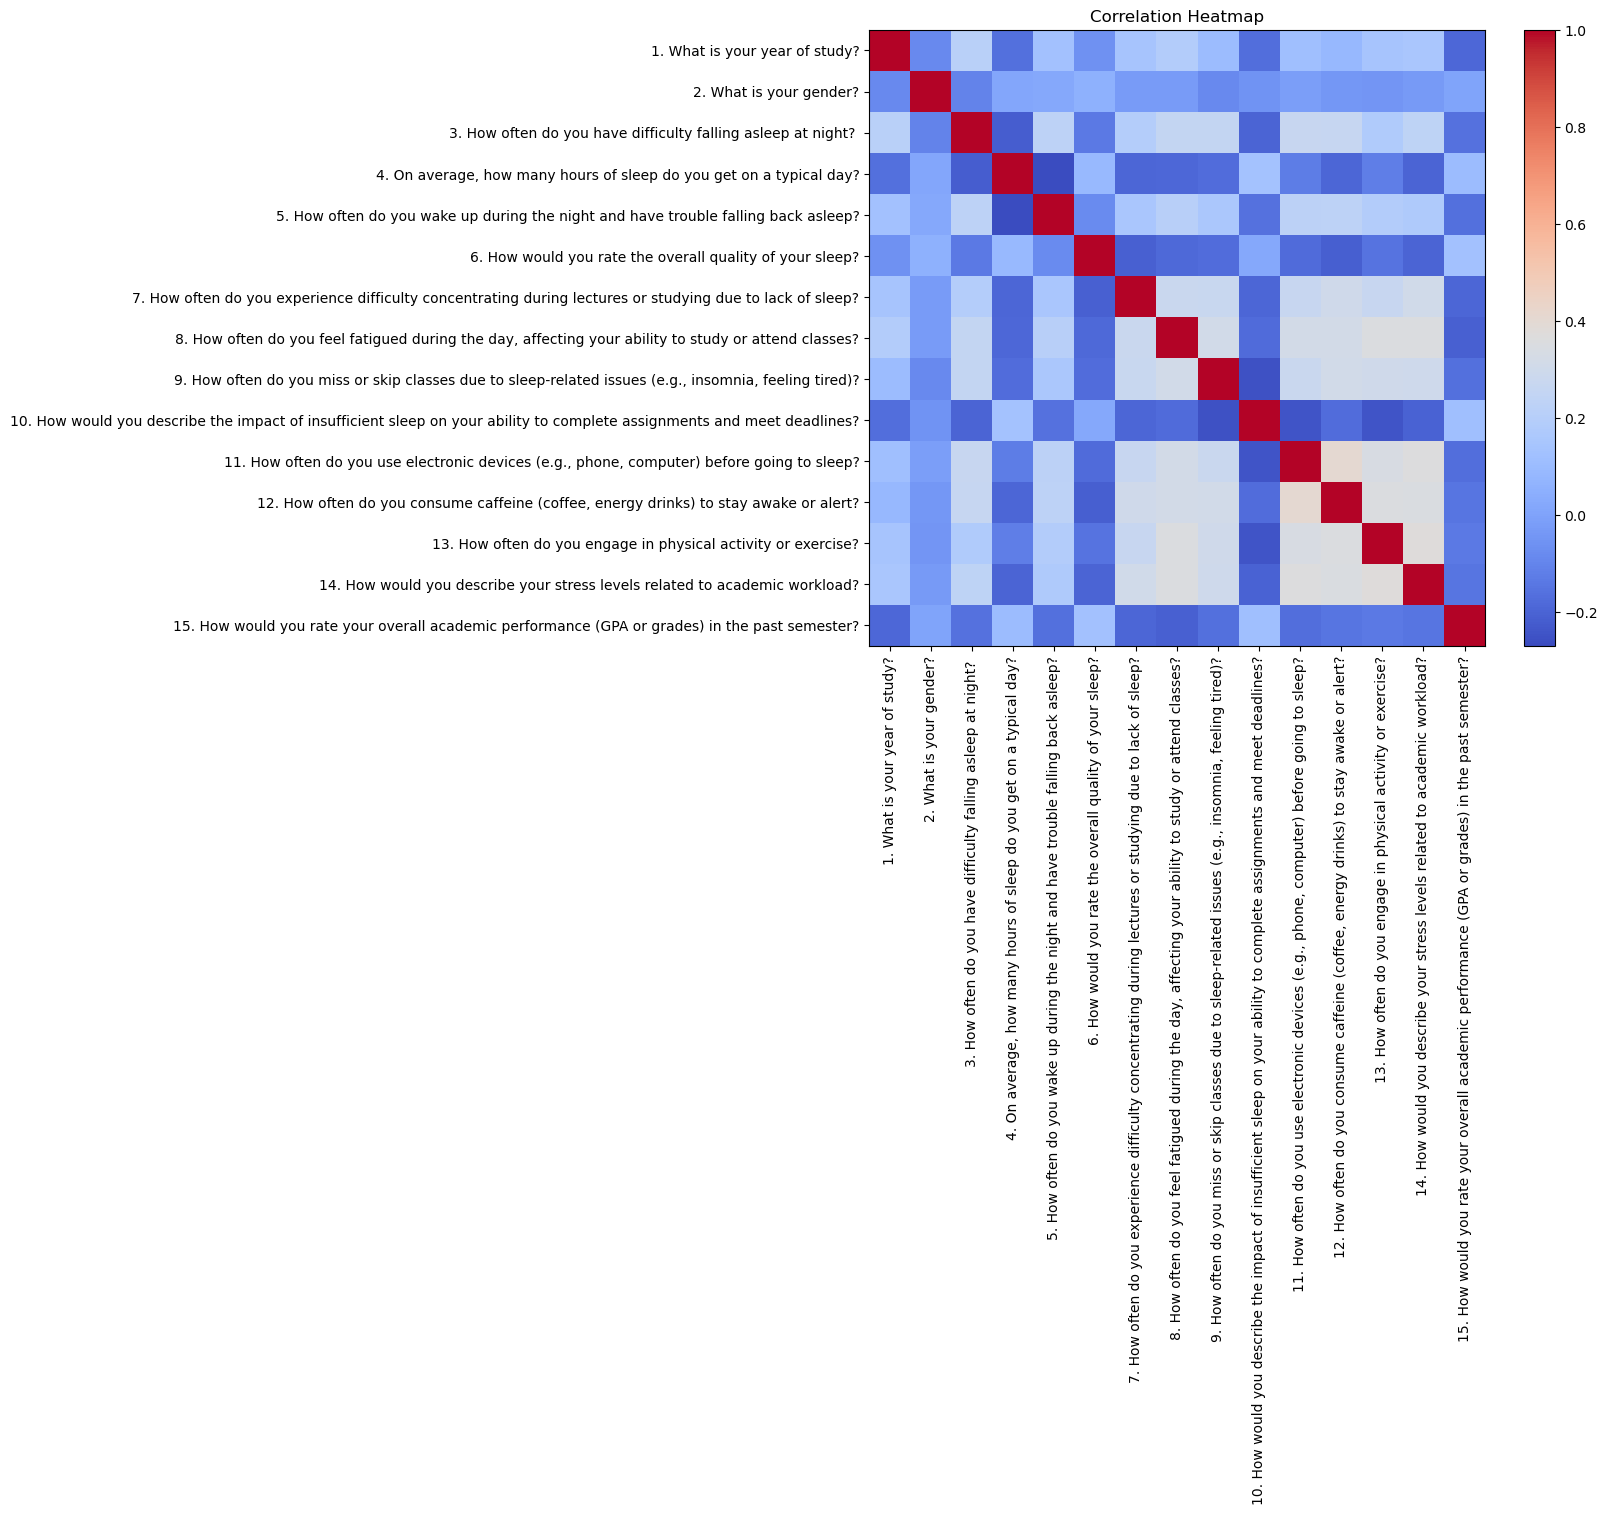

In [9]:
# heatmap for college student dataset
df_numeric = df_student_data.copy()

df_numeric = df_numeric.drop(columns=["Timestamp"])

for col in df_numeric.columns:
    df_numeric[col] = df_numeric[col].astype("category").cat.codes

corr = df_numeric.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap") # heatmap of Student Insomnia and Educational Outcomes Dataset.csv

plt.show()

In [10]:
# download dataset
url = "https://www.cdc.gov/brfss/annual_data/2022/files/LLCP2022XPT.zip"
zip_file = "LLCP2022XPT.zip"

response = requests.get(url, stream=True)
response.raise_for_status()

with open(zip_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

# extract zip
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Download and extraction complete.")

Download and extraction complete.


In [11]:
print(os.listdir())

['caffeine.ipynb', 'LLCP2022.XPT ', 'LLCP2022XPT.zip', 'student_insomnia.ipynb', 'mental_health.ipynb', 'sleep_stress_adult.ipynb']


In [12]:
xpt_file = "./LLCP2022.XPT "
df = pd.read_sas(xpt_file, format="xport")

print("Dataset shape:", df.shape)

print(df.columns.tolist())

Dataset shape: (445132, 328)
['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX1', 'NUMADULT', 'LANDSEX1', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX1', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINSR', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'SLEPTIM1', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COL

In [13]:
sleep_cols = [c for c in df.columns if "SLEEP" in c.upper() or "SLEP" in c.upper()]
print("Sleep-related columns:", sleep_cols)

Sleep-related columns: ['SLEPTIM1']


In [14]:
# only select relevant variables
cols = [
    "_STATE",       # state
    "SEXVAR",       # gender
    "_AGEG5YR",     # age group
    "SLEPTIM1",     # hours of sleep
    "MENTHLTH",     # mental health days
    "_LLCPWT"       # survey weight
]

df_subset = df[cols]

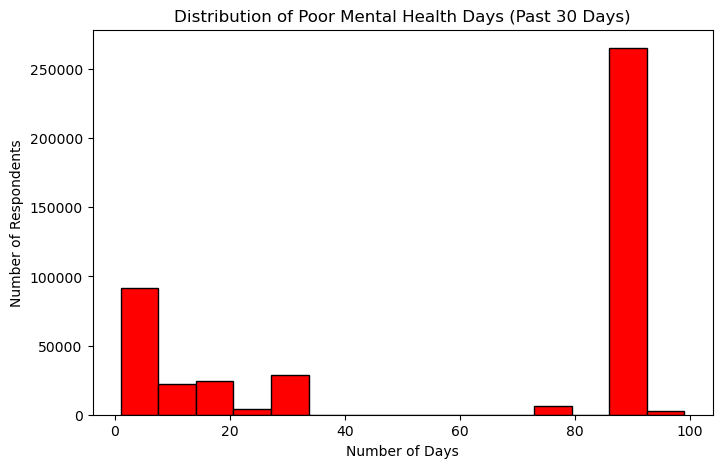

In [15]:
# histogram of poor mental health days for overall adult population data set
plt.figure(figsize=(8,5))
plt.hist(df_subset["MENTHLTH"].dropna(), bins=15, color="red", edgecolor="black")
plt.title("Distribution of Poor Mental Health Days (Past 30 Days)")
plt.xlabel("Number of Days")
plt.ylabel("Number of Respondents")
plt.show()

/var/folders/dk/xnwg_z0n3w56yy6hnjqqbz400000gn/T/ipykernel_10277/3743973849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["short_sleep"] = df_subset["SLEPTIM1"] < 7


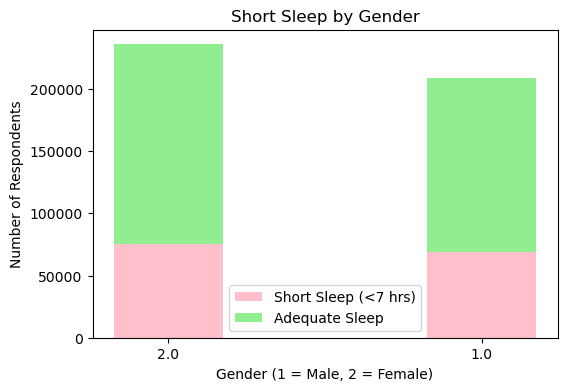

In [16]:
# short sleep by gender in overall adult population data set
df_subset["short_sleep"] = df_subset["SLEPTIM1"] < 7

# count by gender and short sleep
gender_labels = df_subset["SEXVAR"].dropna().unique()
counts = {}
for g in gender_labels:
    counts[g] = [
        ((df_subset["SEXVAR"] == g) & (df_subset["short_sleep"] == True)).sum(),
        ((df_subset["SEXVAR"] == g) & (df_subset["short_sleep"] == False)).sum()
    ]

# Plot
bar_width = 0.35
index = np.arange(len(gender_labels))

plt.figure(figsize=(6,4))
plt.bar(index, [c[0] for c in counts.values()], bar_width, label='Short Sleep (<7 hrs)', color='pink')
plt.bar(index, [c[1] for c in counts.values()], bar_width, bottom=[c[0] for c in counts.values()], label='Adequate Sleep', color='lightgreen')

plt.xticks(index, gender_labels)
plt.xlabel('Gender (1 = Male, 2 = Female)')
plt.ylabel('Number of Respondents')
plt.title('Short Sleep by Gender')
plt.legend()
plt.show()

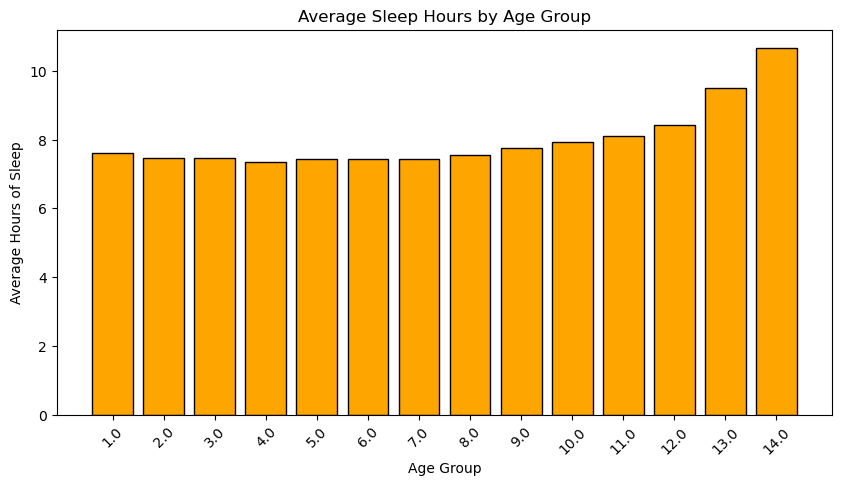

In [17]:
# average sleep hours by age group in overall adult population
age_sleep = df_subset.groupby("_AGEG5YR")["SLEPTIM1"].mean()

plt.figure(figsize=(10,5))
plt.bar(age_sleep.index.astype(str), age_sleep.values, color='orange', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Average Hours of Sleep")
plt.title("Average Sleep Hours by Age Group")
plt.show()

(7, 7)
Index(['_STATE', 'SEXVAR', '_AGEG5YR', 'SLEPTIM1', 'MENTHLTH', '_LLCPWT',
       'short_sleep'],
      dtype='object')


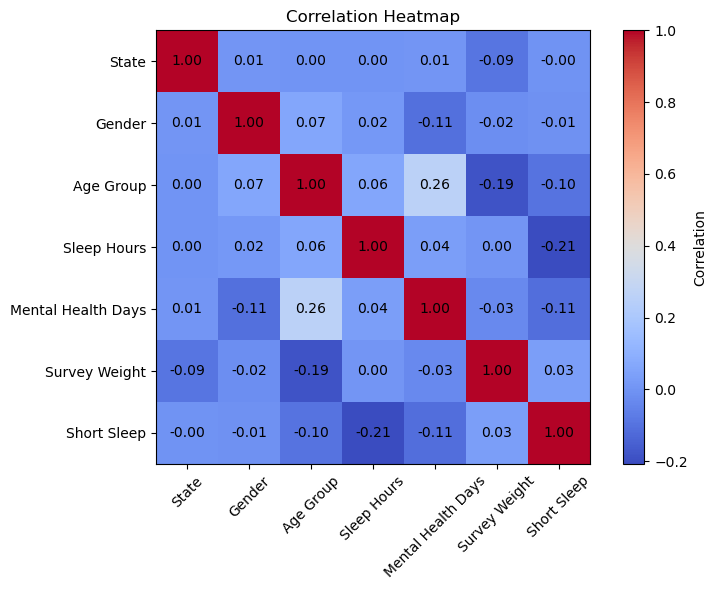

In [18]:
# heatmap for selected variables in overall adult population dataset
corr = df_subset.corr()
print(corr.shape)
print(corr.columns)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(np.arange(len(corr.columns)),
           ["State","Gender","Age Group","Sleep Hours","Mental Health Days","Survey Weight","Short Sleep"],
           rotation=45)

plt.yticks(np.arange(len(corr.columns)),
           ["State","Gender","Age Group","Sleep Hours","Mental Health Days","Survey Weight","Short Sleep"])

# add correlation numbers
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
# map stress responses to numeric scale: Low = 1, Moderate = 2, High = 3
stress_map = {
    "No stress": 1,
    "Low stress": 2,
    "High stress": 3,
    "Extremely high stress": 4
}

df_student_data["Stress_Num"] = df_student_data[
    "14. How would you describe your stress levels related to academic workload?"
].map(stress_map)

# Summary check
print(df_student_data["Stress_Num"].describe())

count    791.000000
mean       3.398230
std        0.634012
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: Stress_Num, dtype: float64


In [20]:
impact_cols = [
    "7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?",
    "8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?",
    "9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",
    "10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"
]
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Always": 4
}

impact_map = {
    "No impact": 0,
    "Minor impact": 1,
    "Moderate impact": 2,
    "Major impact": 3
}

# function to map frequency text to numbers
def map_freq(text):
    for key in freq_map:
        if key in str(text):  
            return freq_map[key]
    return np.nan

# function to map impact text to numbers
def map_impact(text):
    for key in impact_map:
        if key in str(text):
            return impact_map[key]
    return np.nan

# apply mappings
df_student_data["Concentration_Num"] = df_student_data["7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"].apply(map_freq)
df_student_data["Fatigue_Num"] = df_student_data["8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?"].apply(map_freq)
df_student_data["Miss_Classes_Num"] = df_student_data["9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?"].apply(map_freq)
df_student_data["Assignment_Impact_Num"] = df_student_data["10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?"].apply(map_impact)
df_student_data[impact_cols].head()

numeric_cols = ["Concentration_Num", "Fatigue_Num", "Miss_Classes_Num", "Assignment_Impact_Num"]

df_student_data["Academic_Impact"] = df_student_data[numeric_cols].mean(axis=1)

print(df_student_data["Academic_Impact"].describe())

count    791.000000
mean       3.106932
std        0.561767
min        0.666667
25%        3.000000
50%        3.250000
75%        3.500000
max        4.000000
Name: Academic_Impact, dtype: float64


In [21]:
# adult population stress (poor mental health days)
df_subset["Stress_Num"] = df_subset["MENTHLTH"]

df_subset["Daily_Impact"] = df_subset["MENTHLTH"]

# normalize student stress (1–4 scale)
df_student_data["Stress_Normalized"] = (
    (df_student_data["Stress_Num"] - df_student_data["Stress_Num"].min()) /
    (df_student_data["Stress_Num"].max() - df_student_data["Stress_Num"].min())
)

# normalize adult stress (0–30 scale)
df_subset["Stress_Normalized"] = (
    (df_subset["Stress_Num"] - df_subset["Stress_Num"].min()) /
    (df_subset["Stress_Num"].max() - df_subset["Stress_Num"].min())
)

/var/folders/dk/xnwg_z0n3w56yy6hnjqqbz400000gn/T/ipykernel_10277/2173975765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["Stress_Num"] = df_subset["MENTHLTH"]
/var/folders/dk/xnwg_z0n3w56yy6hnjqqbz400000gn/T/ipykernel_10277/2173975765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["Daily_Impact"] = df_subset["MENTHLTH"]
/var/folders/dk/xnwg_z0n3w56yy6hnjqqbz400000gn/T/ipykernel_10277/2173975765.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

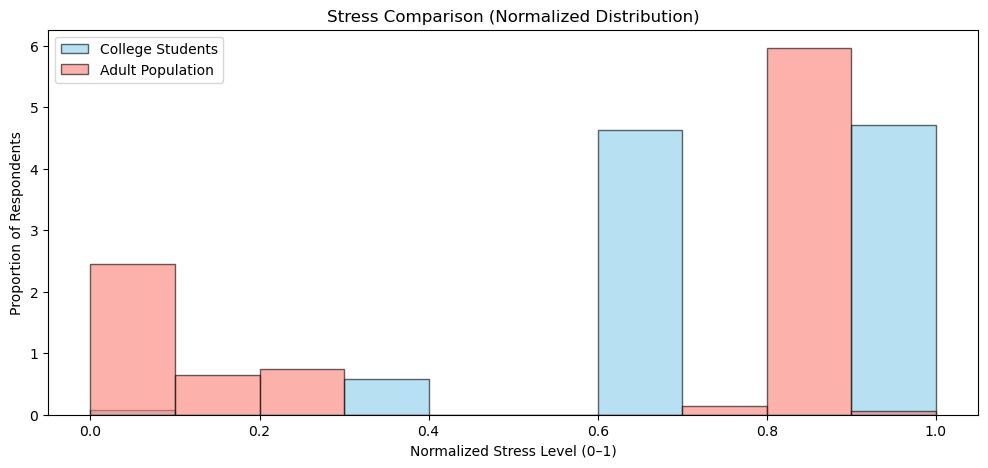

In [22]:
# histogram for normalized stress comparison for college students and overall adult population
plt.figure(figsize=(12,5))

plt.hist(df_student_data["Stress_Normalized"].dropna(),
         bins=10,
         density=True,
         alpha=0.6,
         label="College Students",
         color="skyblue",
         edgecolor="black")

plt.hist(df_subset["Stress_Normalized"].dropna(),
         bins=10,
         density=True,
         alpha=0.6,
         label="Adult Population",
         color="salmon",
         edgecolor="black")

plt.xlabel("Normalized Stress Level (0–1)")
plt.ylabel("Proportion of Respondents")
plt.title("Stress Comparison (Normalized Distribution)")
plt.legend()
plt.show()

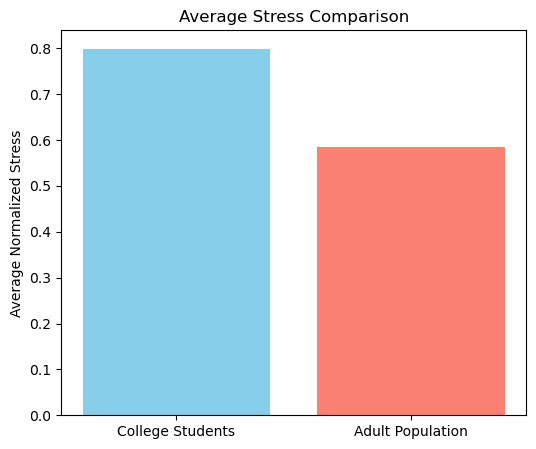

In [23]:
# bar chart for college students and overall adult population
avg_student = df_student_data["Stress_Normalized"].mean()
avg_adult = df_subset["Stress_Normalized"].mean()

plt.figure(figsize=(6,5))

plt.bar(["College Students","Adult Population"],
        [avg_student, avg_adult],
        color=["skyblue","salmon"])

plt.ylabel("Average Normalized Stress")
plt.title("Average Stress Comparison")
plt.show()

/var/folders/dk/xnwg_z0n3w56yy6hnjqqbz400000gn/T/ipykernel_10277/3985399703.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


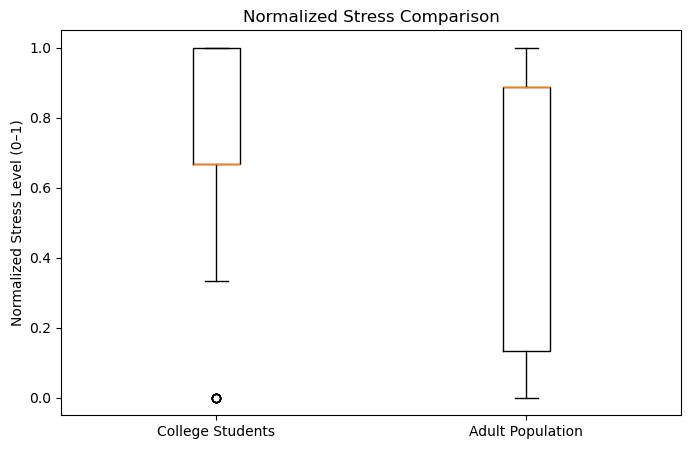

In [24]:
# normalized stress comparison for college students and overall adult population
plt.figure(figsize=(8,5))

plt.boxplot([
    df_student_data["Stress_Normalized"].dropna(),
    df_subset["Stress_Normalized"].dropna()
],
labels=["College Students","Adult Population"])

plt.ylabel("Normalized Stress Level (0–1)")
plt.title("Normalized Stress Comparison")
plt.show()

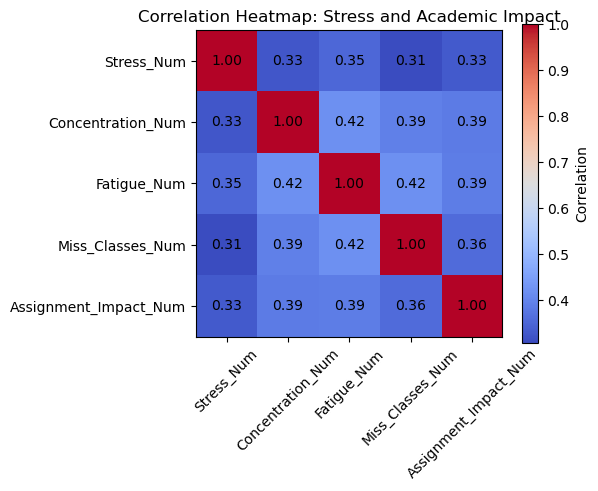

In [25]:
# heatmap for overall adult population data set
corr = df_student_data[
    ["Stress_Num","Concentration_Num","Fatigue_Num","Miss_Classes_Num","Assignment_Impact_Num"]
].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# add correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap: Stress and Academic Impact")
plt.tight_layout()
plt.show()